<a href="https://colab.research.google.com/github/vischia/adfm/blob/master/00_profile_likelihood.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Profile Likelihood Fits
C) Pietro Vischia, 2026

Prepared with assistance from CODEX with GPT-5.6.

We will work through **one small counting experiment**. There are three short exercises,
and all the code is provided. Run the cells in order; pause at the exercises to predict
what will happen.

Our questions are:

1. How do we estimate a signal when some counted events are background?
2. How do we allow for uncertainty in that background?
3. If we repeat the experiment, how often does our interval contain the true signal?
4. How much of our final uncertainty comes from the background measurement?


In [2]:
# If you run in colab,  uncomment this and run it>

# pip install iminuit numpy scipy matplotlib pandas

In [1]:
import sys
import numpy as np
import scipy
from scipy.special import xlogy   # A safe way to calculate count * log(expected count).
import matplotlib
import matplotlib.pyplot as plt
import iminuit
from iminuit import Minuit

%matplotlib inline

plt.rcParams.update({"figure.dpi": 120, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.2,
                     "figure.constrained_layout.use": True})

# A one-standard-deviation Gaussian interval contains 68.27% of the distribution.
# We use this level throughout and call it "about 68%" in the explanations.
CONFIDENCE = 0.682689492137

print("Python:", sys.version.split()[0], "| iminuit:", iminuit.__version__)
print("NumPy:", np.__version__, "| SciPy:", scipy.__version__,
      "| Matplotlib:", matplotlib.__version__)

Python: 3.10.21 | iminuit: 2.32.0
NumPy: 2.2.5 | SciPy: 1.15.3 | Matplotlib: 3.10.9


## 1. Our experiment: count here, check the background nearby

Imagine looking for a new particle in a small interval of reconstructed mass.
That interval is our **signal region**. It can contain both signal and background events.
We also count events in a nearby **sideband**, where we assume there is background but no signal.

For this simple example, the sideband is twice as large and the background rate is flat.
We therefore expect twice as many background events there as in the signal region.

| Region | What we observe | What we expect on average |
|---|---:|---:|
| Signal region | $n=70$ events | signal + background: $s+b$ |
| Sideband | $m=100$ events | twice the background: $2b$ |

Here $s$ and $b$ are **unknown average counts**, not labels attached to individual events.
An average count can be a noninteger. The observed counts $n$ and $m$ are integers.

* The quantity we want to measure is $s$: the **parameter of interest**.
* We also need to estimate $b$: a **nuisance parameter**.
  “Nuisance” just means that it is needed in the model but is not our main result.

We call the sideband-to-signal-region size ratio `tau`. Here `tau = 2`, and we treat it as exactly known.

### Exercise 1 — estimate before fitting

Use the sideband to estimate the background in the signal region. Subtract that estimate
from 70. What signal count do you expect the fit to find?

Write your two numbers here before continuing: **background = … ; signal = …**

In [2]:
# These are the measured data for ONE experiment.
n_observed = 70
m_observed = 100
tau = 2.0

background_guess = m_observed / tau
signal_guess = n_observed - background_guess

print(f"Background estimate: {background_guess:.1f} events")
print(f"Signal estimate:     {signal_guess:.1f} events")

Background estimate: 50.0 events
Signal estimate:     20.0 events


### Why is the background estimate uncertain?

If we repeated the experiment, we would not always count exactly 100 sideband events.
For independent counting events, a **Poisson distribution** is a useful model.
Its standard deviation is the square root of its mean.

Using the observed count as an estimate of that mean, the sideband count has an approximate
uncertainty $\sqrt{100}=10$. Dividing the count by 2 also divides its uncertainty by 2:

$$b\ \text{is estimated as}\ 50\ \text{with an approximate uncertainty of}\ 5\ \text{events}.$$

So we should not treat the number 50 as perfectly known. The fit below includes the
sideband measurement and lets the background vary.

## 2. A likelihood is a way to compare possible explanations

Suppose we try particular values of $s$ and $b$. The probability of seeing our two counts is

$$L(s,b)=\operatorname{Poisson}(70\mid s+b)\times\operatorname{Poisson}(100\mid 2b).$$

Read this as: **probability of our signal-region count, times probability of our sideband count**.
Multiplication is appropriate because the two regions contain different, independent events.
When the data are fixed and we vary the proposed parameters, we call this expression a **likelihood**.

The best fit chooses the parameter values with the largest likelihood.
Computers often do the equivalent calculation of minimizing the **negative log-likelihood**, or NLL:

$$\mathrm{NLL}(s,b)=(s+b)-n\log(s+b)+\tau b-m\log(\tau b).$$

We have left out terms that are the same for every parameter choice. They cannot change the best fit.
You do not need to derive this formula for the exercise; it comes from taking the logarithm
of the two Poisson probabilities.

**Where did the uncertainty enter?** The second Poisson term is the sideband measurement.
It discourages background values that fit that measurement poorly. It is often called a
**constraint term**. It still allows background values other than exactly 50.
It describes measured data; it is not a probability distribution for the unknown true $b$.

In [3]:
def nll(signal, background, n, m):
    """A lower value means a better explanation of the two observed counts."""
    expected_signal_region = signal + background
    expected_sideband = tau * background

    # Expected event counts cannot be negative.
    if expected_signal_region < 0 or expected_sideband < 0:
        return np.inf

    # xlogy(n, mean) means n * log(mean), including the case n = mean = 0.
    signal_region_term = expected_signal_region - xlogy(n, expected_signal_region)
    sideband_term = expected_sideband - xlogy(m, expected_sideband)
    return signal_region_term + sideband_term

### Let iminuit search for the best values

The next cell is a small helper we will reuse. Its main instruction is `migrad()`:
“adjust the free parameters until the NLL is as small as possible.”
The optional `fix_...` arguments will let us hold a parameter fixed later.
You can use this helper without learning every iminuit setting today.

In [4]:
def fit_counts(n, m, fix_signal=None, fix_background=None):
    """Fit one pair of counts. Usually both signal and background can move."""
    # The counts stay fixed during this fit; only signal and background can change.
    def cost(signal, background):
        return nll(signal, background, n, m)

    fit = Minuit(cost,
                 signal=max(n - m/tau, 0.1),
                 background=max(m/tau, 0.1))

    # Tell iminuit that our function is -log(likelihood).
    # This setting is necessary for correctly scaled uncertainties.
    fit.errordef = Minuit.LIKELIHOOD
    fit.limits["signal"] = (0, None)      # No negative expected signal count.
    fit.limits["background"] = (0, None)  # No negative expected background count.
    fit.tol = 1e-5

    if fix_signal is not None:
        fit.values["signal"] = fix_signal
        fit.fixed["signal"] = True
    if fix_background is not None:
        fit.values["background"] = fix_background
        fit.fixed["background"] = True

    fit.migrad()  # Find the minimum.
    if not fit.valid:
        fit.simplex().migrad()  # Retry on the same data, with a different search strategy.
    if not fit.valid:
        raise RuntimeError("This fit failed. Inspect it rather than using its result.")
    return fit

In [5]:
best_fit = fit_counts(n_observed, m_observed)
best_signal = best_fit.values["signal"]
best_background = best_fit.values["background"]
best_nll = best_fit.fval

print(f"Best-fitting signal:     {best_signal:.2f} events")
print(f"Best-fitting background: {best_background:.2f} events")
print("Fit found a valid minimum:", best_fit.valid)

Best-fitting signal:     20.00 events
Best-fitting background: 50.00 events
Fit found a valid minimum: True


## 3. What does “profile the background” mean?

The best signal estimate is 20 events. To find its uncertainty, we also try nearby possibilities.
For example, could 30 signal events describe the data reasonably well?

For **each** signal value we try, we let the background find its best value again:

1. Hold the proposed signal count fixed.
2. Adjust the background to fit both measured regions as well as possible.
3. Record how much worse this fit is than the overall best fit.

This is **profiling**. We give every proposed signal value its best possible background explanation,
while still taking the sideband measurement into account.

Our measure of how much worse the fit becomes is

$$\text{score}(s)=2\,[\mathrm{NLL}_{\text{best background at this }s}-\mathrm{NLL}_{\text{overall best fit}}].$$

It is zero at the best fit and positive elsewhere. Its technical name is the
**profile likelihood-ratio statistic**. The factor of 2 is a useful statistical convention.

### Exercise 2 — predict the movement

If we try a larger signal count, should the fitted background tend to increase or decrease?
Explain your prediction using the total count in the signal region.

In [6]:
# A few examples make the profiling operation visible.
print("Tried signal     Best background")
for trial_signal in [0, 10, 20, 30, 40]:
    trial_fit = fit_counts(n_observed, m_observed, fix_signal=trial_signal)
    print(f"{trial_signal:8.0f}         {trial_fit.values['background']:8.2f}")

Tried signal     Best background
       0            56.67
      10            52.96
      20            50.00
      30            47.65
      40            45.79


Notice that the background does not have to change by exactly the opposite amount to the signal.
It must compromise between explaining the signal region and explaining the sideband.

### From the curve to an interval

For many sufficiently well-measured problems, signal values with **score ≤ 1** form an
approximately 68% confidence interval. This rule is an approximation; we will check it by
repeating the experiment in Part 5.

iminuit's **MINOS** method follows this profile curve to find the interval endpoints.
It varies the background during that search. The code below asks MINOS for those endpoints.

In [7]:
def interval_68(fit):
    """Ask MINOS for an approximately 68% interval in the signal count."""
    fit.minos("signal", cl=CONFIDENCE)
    errors = fit.merrors["signal"]
    if not errors.is_valid:
        raise RuntimeError("MINOS could not find a valid interval. Inspect this fit.")

    # MINOS stores changes relative to the fitted value, not the endpoints themselves.
    lower = fit.values["signal"] + errors.lower
    upper = fit.values["signal"] + errors.upper
    return max(0.0, lower), upper


lower_total, upper_total = interval_68(best_fit)
print(f"Signal estimate: {best_signal:.1f} events")
print(f"Approximately 68% interval: [{lower_total:.1f}, {upper_total:.1f}] events")
print(f"Distance below the estimate: {best_signal-lower_total:.1f} events")
print(f"Distance above the estimate: {upper_total-best_signal:.1f} events")

Signal estimate: 20.0 events
Approximately 68% interval: [10.4, 30.0] events
Distance below the estimate: 9.6 events
Distance above the estimate: 10.0 events


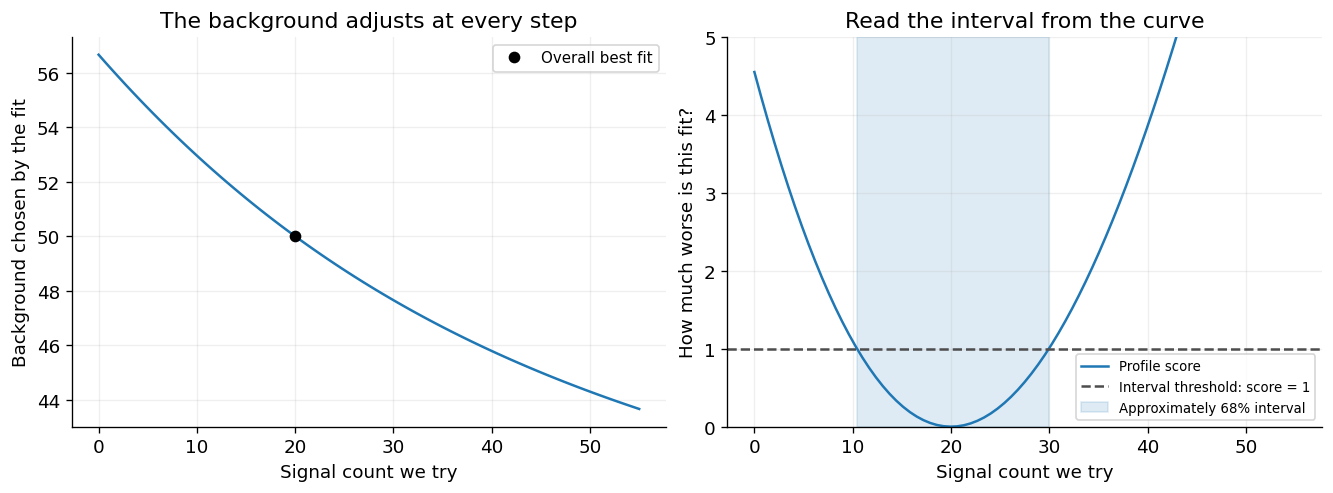

In [8]:
# Scan a range of proposed signal counts for the plots.
signal_grid = np.linspace(0, 55, 81)
profile_scores = []
profile_backgrounds = []

for trial_signal in signal_grid:
    trial_fit = fit_counts(n_observed, m_observed, fix_signal=float(trial_signal))
    profile_scores.append(2 * (trial_fit.fval - best_nll))
    profile_backgrounds.append(trial_fit.values["background"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(signal_grid, profile_backgrounds)
axes[0].plot(best_signal, best_background, "ko", label="Overall best fit")
axes[0].set(xlabel="Signal count we try", ylabel="Background chosen by the fit",
            title="The background adjusts at every step")
axes[0].legend(fontsize=9)

axes[1].plot(signal_grid, profile_scores, label="Profile score")
axes[1].axhline(1, color="0.3", ls="--", label="Interval threshold: score = 1")
axes[1].axvspan(lower_total, upper_total, color="C0", alpha=0.14,
                label="Approximately 68% interval")
axes[1].set(xlabel="Signal count we try", ylabel="How much worse is this fit?",
            title="Read the interval from the curve", ylim=(0, 5))
axes[1].legend(fontsize=8)
plt.show()

**Read the plots:** the left plot shows the nuisance parameter moving. The right plot
shows which proposed signal counts are still reasonably compatible with the data.
The shaded interval includes uncertainty from both measured counts.

## 4. Freeze the background: what changes?

Now hold the background at its fitted value, 50, for every proposed signal count.
This is called **freezing** a nuisance parameter. During this calculation it is treated as exactly known.

The remaining uncertainty comes from the signal-region count. We call it the **signal-region
counting contribution**. This name is more precise than just calling it “statistical uncertainty,”
because the sideband itself also has counting uncertainty.

Freezing should make the interval narrower: the fit has lost the freedom to adjust the background.
But we have not taken any new data. The smaller interval therefore does **not** represent the
full uncertainty of our original measurement.

Background profiled: [10.4, 30.0] events
Background frozen:  [12.0, 28.7] events


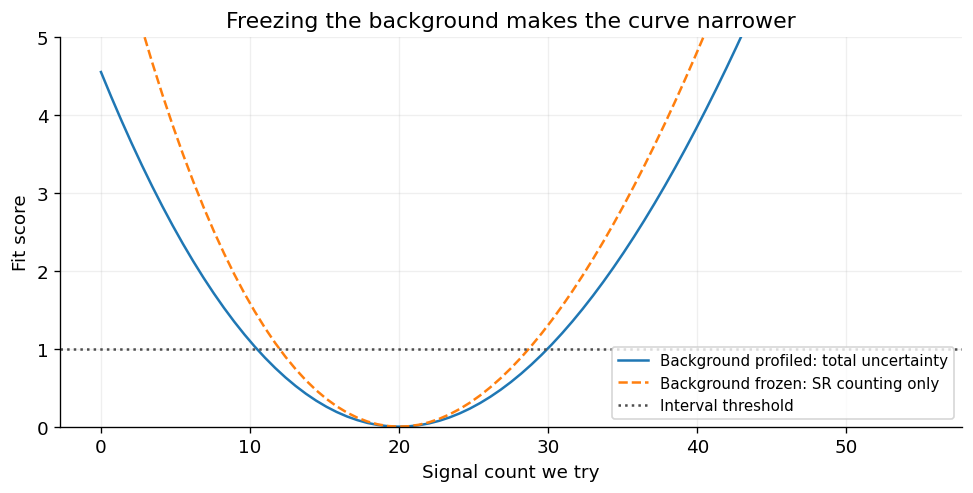

In [9]:
# Freeze at the background value from the original full fit.
# Do not freeze at an invented value or at a value known only in a simulation.
frozen_fit = fit_counts(n_observed, m_observed, fix_background=best_background)
lower_frozen, upper_frozen = interval_68(frozen_fit)

frozen_scores = []
for trial_signal in signal_grid:
    fixed_nll = nll(trial_signal, best_background, n_observed, m_observed)
    frozen_scores.append(2 * (fixed_nll - frozen_fit.fval))

print(f"Background profiled: [{lower_total:.1f}, {upper_total:.1f}] events")
print(f"Background frozen:  [{lower_frozen:.1f}, {upper_frozen:.1f}] events")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(signal_grid, profile_scores, label="Background profiled: total uncertainty")
ax.plot(signal_grid, frozen_scores, "--", label="Background frozen: SR counting only")
ax.axhline(1, color="0.3", ls=":", label="Interval threshold")
ax.set(xlabel="Signal count we try", ylabel="Fit score", ylim=(0, 5),
       title="Freezing the background makes the curve narrower")
ax.legend(fontsize=9)
plt.show()

### Split the uncertainty into two contributions

Our two intervals are nearly symmetric. To summarize each by one number, use **half its width**.
For these almost bowl-shaped likelihood curves, this is approximately a standard error.

Independent standard errors combine by adding their **squares**, not by adding the errors themselves.
For this simple example, we therefore describe the uncertainty using the approximate split

$$\sigma_{\text{total}}^2\approx\sigma_{\text{SR counting}}^2+\sigma_{\text{sideband}}^2.$$

The total comes from the profile fit. The SR counting part comes from the frozen fit.
We infer the sideband contribution by subtraction:

$$\sigma_{\text{sideband}}\approx
\sqrt{\sigma_{\text{total}}^2-\sigma_{\text{SR counting}}^2}.$$

This is an approximate way to describe the uncertainty budget. It works well for this example;
it is not a new confidence interval or an exact rule for all likelihoods. In particular, do not
use this simple recipe if an interval reaches zero or is strongly asymmetric.

In [10]:
# Turn the nearly symmetric intervals into approximate standard errors.
error_total = (upper_total - lower_total) / 2
error_sr = (upper_frozen - lower_frozen) / 2
error_sideband = np.sqrt(error_total**2 - error_sr**2)

print("Uncertainty budget, in signal events:")
print(f"  Total:                 {error_total:.1f}")
print(f"  Signal-region count:   {error_sr:.1f}")
print(f"  Sideband measurement:  {error_sideband:.1f}")

# Elementary cross-check: a Poisson count has approximate uncertainty sqrt(count).
print("\nSimple counting estimates for comparison:")
print(f"  Signal-region part: sqrt(n)       = {np.sqrt(n_observed):.2f}")
print(f"  Sideband part: sqrt(m) / tau      = {np.sqrt(m_observed)/tau:.2f}")
print(f"  Total: sqrt(n + m / tau squared) = {np.sqrt(n_observed + m_observed/tau**2):.2f}")

Uncertainty budget, in signal events:
  Total:                 9.8
  Signal-region count:   8.4
  Sideband measurement:  5.0

Simple counting estimates for comparison:
  Signal-region part: sqrt(n)       = 8.37
  Sideband part: sqrt(m) / tau      = 5.00
  Total: sqrt(n + m / tau squared) = 9.75


### Is the sideband contribution a “systematic uncertainty”?

Analyses often use nuisance parameters to represent background uncertainties and may group
some of them under the label **systematic**. In our example, the background uncertainty comes
specifically from the limited number of sideband events: its source is statistical.

The important point is the method: **include the auxiliary measurement in the likelihood,
then let its nuisance parameter move during the fit**. A detector calibration could be represented
by another auxiliary measurement using the same idea. We keep only the sideband here.

If you choose to call all counting fluctuations “statistical,” both pieces above are statistical.
Changing the label does not change the total uncertainty.

## 5. Does “68% interval” really mean 68%?

To check, imagine doing the whole experiment many times. We can simulate this on a computer.
A simulated experiment is often called a **toy experiment**.

For this study, suppose nature has a true mean signal of 30 events and a true mean background of 50.
These two true values stay fixed. In each repetition:

1. Draw a new signal-region count with mean $30+50=80$.
2. Draw a new sideband count with mean $2\times50=100$.
3. Fit those two counts and calculate an interval.
4. Check whether the interval contains the true signal value, 30.

The fraction of intervals that contain the true value is called **coverage**.
For example, 680 successes out of 1,000 repetitions would mean 68% measured coverage.

Both counts must fluctuate: both are measurements in the experiment we are repeating.
We do not draw a different true background for each toy. Nature's true mean is fixed;
the observed number of events fluctuates.

We will also calculate a frozen-background interval in each toy. Each toy freezes its
background at **its own fitted value**, just as we did with the observed data.

In [11]:
# You can change these values and rerun this section after completing the notebook.
true_signal = 30.0
true_background = 50.0
number_of_toys = 1000
rng = np.random.default_rng(2026)  # A seed makes the classroom results reproducible.

# Each row will hold [lower endpoint, upper endpoint] for one toy.
total_intervals = np.empty((number_of_toys, 2))
frozen_intervals = np.empty((number_of_toys, 2))

for toy_index in range(number_of_toys):
    # Repeat BOTH measurements, while keeping the true averages fixed.
    n_toy = rng.poisson(true_signal + true_background)
    m_toy = rng.poisson(tau * true_background)

    toy_fit = fit_counts(n_toy, m_toy)
    total_intervals[toy_index] = interval_68(toy_fit)

    toy_frozen_fit = fit_counts(
        n_toy, m_toy, fix_background=toy_fit.values["background"])
    frozen_intervals[toy_index] = interval_68(toy_frozen_fit)

    # A little progress feedback for slower computers.
    if (toy_index + 1) % 250 == 0:
        print(f"Completed {toy_index + 1} / {number_of_toys} toys")

print("Every generated toy was included. A failed fit would stop this calculation.")

Completed 250 / 1000 toys
Completed 500 / 1000 toys
Completed 750 / 1000 toys
Completed 1000 / 1000 toys
Every generated toy was included. A failed fit would stop this calculation.


In [12]:
# An interval covers if its lower end is below the truth and its upper end is above it.
covers_total = ((total_intervals[:, 0] <= true_signal)
                & (true_signal <= total_intervals[:, 1]))
covers_frozen = ((frozen_intervals[:, 0] <= true_signal)
                 & (true_signal <= frozen_intervals[:, 1]))

coverage_total = np.mean(covers_total)    # The mean of True/False values is the success fraction.
coverage_frozen = np.mean(covers_frozen)

# The estimated fraction is also uncertain because we simulated a finite number of toys.
# This is the usual standard error for a success fraction p from N independent trials.
mc_error_total = np.sqrt(coverage_total * (1-coverage_total) / number_of_toys)
mc_error_frozen = np.sqrt(coverage_frozen * (1-coverage_frozen) / number_of_toys)

print(f"Target: about {100*CONFIDENCE:.1f}%")
print(f"Profile intervals: {100*coverage_total:.1f}% +/- {100*mc_error_total:.1f} percentage points")
print(f"Frozen intervals:  {100*coverage_frozen:.1f}% +/- {100*mc_error_frozen:.1f} percentage points")
print("The +/- numbers describe simulation precision, not uncertainty in the signal count.")

Target: about 68.3%
Profile intervals: 70.6% +/- 1.4 percentage points
Frozen intervals:  61.8% +/- 1.5 percentage points
The +/- numbers describe simulation precision, not uncertainty in the signal count.


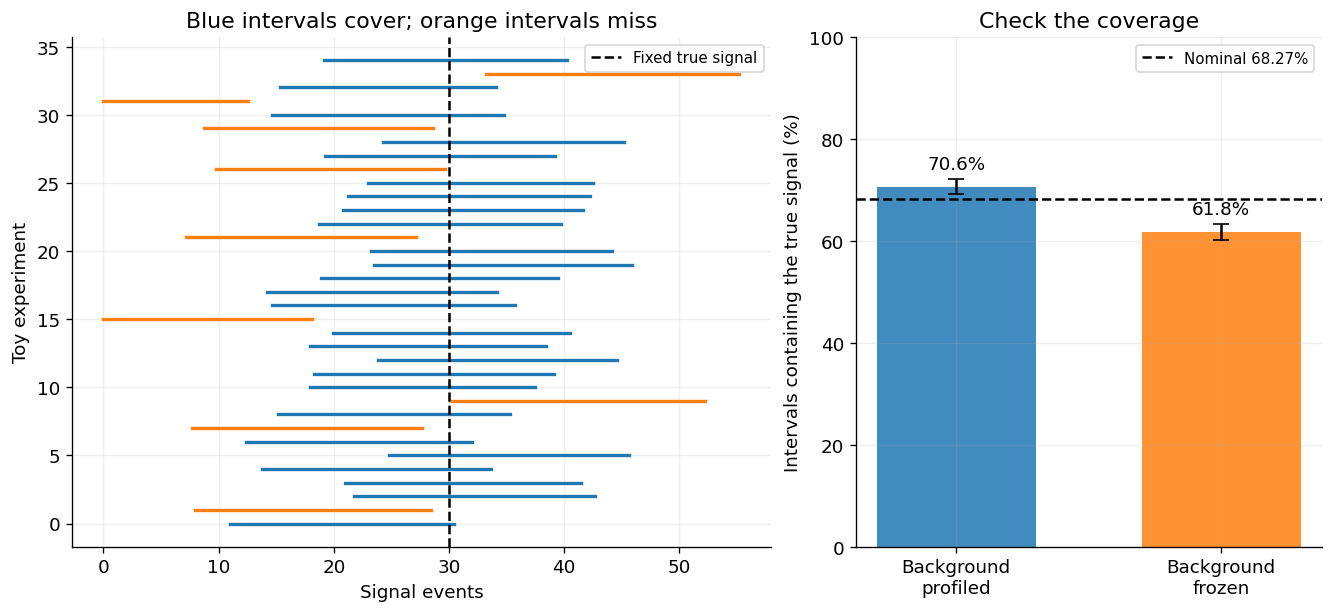

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), gridspec_kw={"width_ratios": [1.5, 1]})

# Show a small selection of the full profile intervals.
for toy_index in range(min(35, number_of_toys)):
    color = "C0" if covers_total[toy_index] else "C1"
    axes[0].plot(total_intervals[toy_index], [toy_index, toy_index], color=color, lw=2)
axes[0].axvline(true_signal, color="black", ls="--", label="Fixed true signal")
axes[0].set(xlabel="Signal events", ylabel="Toy experiment",
            title="Blue intervals cover; orange intervals miss")
axes[0].legend(fontsize=9)

# Compare the success fractions for the two interval procedures.
percentages = 100 * np.array([coverage_total, coverage_frozen])
simulation_errors = 100 * np.array([mc_error_total, mc_error_frozen])
axes[1].bar([0, 1], percentages, yerr=simulation_errors, capsize=5,
            color=["C0", "C1"], alpha=0.85, width=0.6)
axes[1].axhline(100*CONFIDENCE, color="black", ls="--", label="Nominal 68.27%")
axes[1].set_xticks([0, 1], ["Background\nprofiled", "Background\nfrozen"])
axes[1].set(ylabel="Intervals containing the true signal (%)", ylim=(0, 100),
            title="Check the coverage")
axes[1].legend(fontsize=9, loc="upper right")
for x, y, error in zip([0, 1], percentages, simulation_errors):
    axes[1].text(x, y + error + 2, f"{y:.1f}%", ha="center")
plt.show()

### What should we learn from the repetitions?

The profile intervals should cover close to 68% in this example. They will not cover exactly
68% in a finite simulation, and the score = 1 rule is itself an approximation.

**Reading the small error bars:** they show the uncertainty from using a finite number of
simulated experiments. Each bar spans one standard error on either side of the measured fraction.
It is normal for a result to differ from its target by one or sometimes two such errors.
These bars are not limits within which every simulation must land.

The frozen intervals tend to miss the truth more often. They are narrower, but they ignore
the fact that the fitted background changes from one experiment to the next.
Covering less often than the stated confidence level is called **undercoverage**.

Coverage describes **the method over repeated data**. It does not mean that the true signal
changes between experiments, or that 68% of the observed events are signal.

### Exercise 3 — explain the result

In two or three sentences, explain why the frozen interval is narrower but is not a suitable
total error bar for this measurement. Use the coverage plot as evidence.

If you have time, change `number_of_toys` to 2000 and rerun Part 5. More toys should make the
estimated coverage more precise. They do not repair an interval method that misses too often.

### A small limitation to remember

We chose reasonably large counts and a positive signal away from zero. With very few events,
or a true signal close to the allowed boundary $s=0$, the score = 1 rule can have coverage quite
different from 68%. MINOS finds the crossings of the curve; it does not guarantee the coverage.
The same simulation idea can be used to investigate those cases in a later course.

## 6. Take-home ideas

| Idea | Meaning in this experiment |
|---|---|
| Fit | Find the signal and background that best describe both counts. |
| Nuisance parameter | The background is unknown, even though the signal is our main interest. |
| Auxiliary measurement | The sideband provides information about the background. |
| Profile | For every proposed signal, refit the background. |
| Freeze | Hold the background at one value; its uncertainty no longer contributes. |
| Coverage | The fraction of repeated intervals containing the fixed true signal. |
| Uncertainty split | Compare the full and frozen errors under a stated approximation. |

For the default measured counts, the fitted signal is **20 events**. Its total error is about
**9.8 events**, with approximate contributions of **8.4 events** from signal-region counting
and **5.0 events** from the sideband measurement. The contributions combine through their
squares. The profile interval gives the more precise, slightly asymmetric result.

# 7. Evaluation

Save (to send during the week when the tarea will be available) the fitted signal and its interval, the two measured coverages, and your answers to Exercises 1,2, and 3. You do not need to reproduce the code.